<a href="https://colab.research.google.com/github/aKrish23-luffy/Project/blob/main/Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

plt.style.use('fivethirtyeight')

            sales
date             
2021-01-31    111
2021-02-28    115
2021-03-31    111
2021-04-30    120
2021-05-31    119


/tmp/ipykernel_5391/942967257.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_rng = pd.date_range(start='2021-01-01', periods=36, freq='M')


<Axes: title={'center': 'Historical Sales Data'}, xlabel='date'>

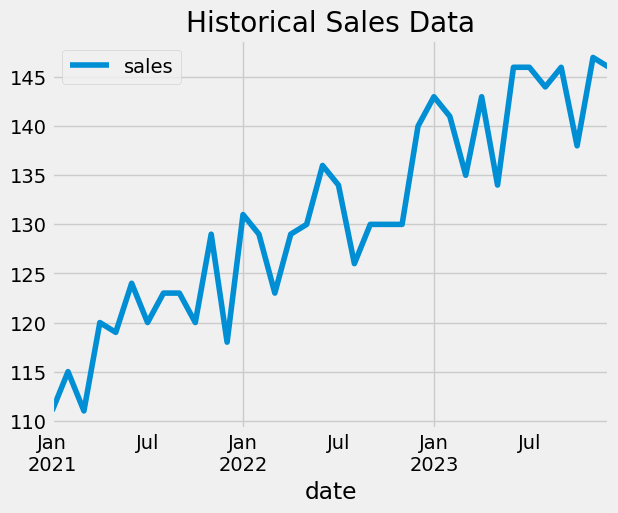

In [2]:
date_rng = pd.date_range(start='2021-01-01', periods=36, freq='M')
data = pd.DataFrame(date_rng, columns=['date'])
data['sales'] = [100 + x + (np.random.randint(5, 20)) for x in range(36)]
data.set_index('date', inplace=True)

print(data.head())
data.plot(title="Historical Sales Data")

In [3]:
train_size = int(len(data) * 0.8)
train, test = data[0:train_size], data[train_size:len(data)]

model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Root Mean Squared Error (RMSE): 4.71
Mean Absolute Percentage Error (MAPE): 3.20%


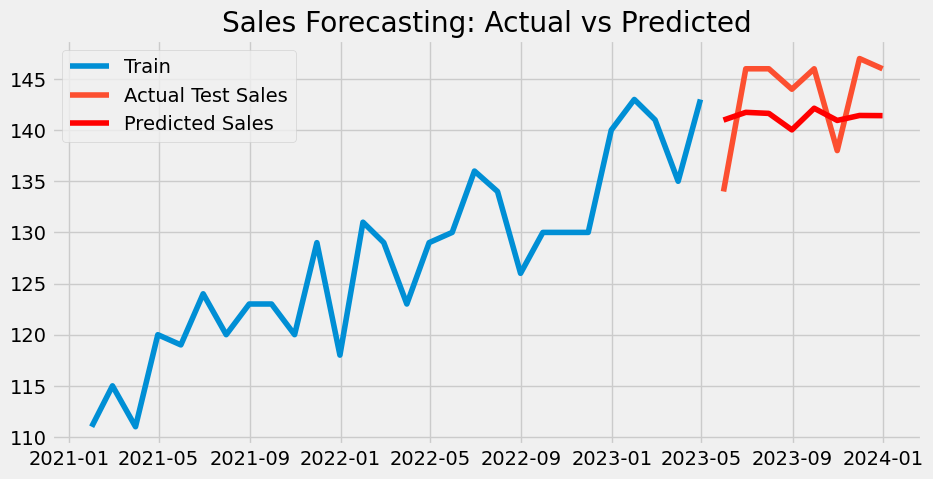

In [4]:
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")

plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual Test Sales')
plt.plot(test.index, forecast, label='Predicted Sales', color='red')
plt.legend()
plt.title("Sales Forecasting: Actual vs Predicted")
plt.show()